# This notebook reproduces following figures: Fig. 6, Fig. 7.

Following network files were used to simulate the networks:
- nw_iall_pattern_separation_stim.py
- nw_iall_pattern_separation_inhib.py
- nw_ie_pattern_separation_stim.py
- nw_ie_pattern_separation_inhib.py

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

## Fig 6: Co-active ISP improves stimulation-driven recall of overlapping engrams.

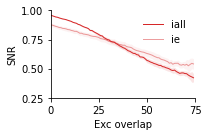

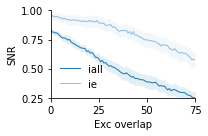

In [6]:
SHOW_SEM = True
EPS = 1e-12

CSV_IALL = "data/fig6_7/iall_pattern_separation_stim_rates_summary_corrected.csv"
CSV_IE   = "data/fig6_7/ie_pattern_separation_stim_rates_summary_corrected.csv"

BLUE = "#1f77b4" 
RED  = "#d62728" 

def load_and_compute(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    needed_cols = [
        "seed",
        "overlap_exc", "overlap_inh",
        "exc_rate_196_784", "exc_rate_784_1568_minus_7ov",
        "inh_rate_0_196", "inh_rate_196_392_minus_7ov",
    ]
    for c in needed_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df[df["overlap_inh"] == 27].copy()

    df["x"] = df["overlap_exc"] * 7.0 * 100.0 / 784.0

    S_exc = df["exc_rate_196_784_minus_7ov"]
    N_exc = df["exc_rate_784_1568_minus_7ov"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    S_inh = df["inh_rate_0_196_minus_7ov"]
    N_inh = df["inh_rate_196_392_minus_7ov"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    df["case"] = label
    return df[["x", "seed", "sn_exc", "sn_inh", "case"]].dropna(subset=["x"])

def aggregate_mean_sem(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    g = df.groupby("x")[ycol]
    out = g.mean().rename("mean").to_frame().reset_index()
    if SHOW_SEM:
        n = g.count().rename("n").reset_index()
        sd = g.std(ddof=1).rename("sd").reset_index()
        out = out.merge(n, on="x").merge(sd, on="x")
        out["sem"] = out["sd"] / np.sqrt(out["n"].replace(0, np.nan))
    else:
        out["sem"] = np.nan
    return out.sort_values("x")

df_iall = load_and_compute(CSV_IALL, "iall")
df_ie   = load_and_compute(CSV_IE,   "ie")

agg_iall_exc = aggregate_mean_sem(df_iall, "sn_exc")
agg_ie_exc   = aggregate_mean_sem(df_ie,   "sn_exc")

fig1, ax1 = plt.subplots(figsize=(3, 2))

ax1.plot(agg_iall_exc["x"], agg_iall_exc["mean"],
         color=RED, linewidth=1, label="iall")
ax1.plot(agg_ie_exc["x"], agg_ie_exc["mean"],
         color=RED, linewidth=1, alpha=0.45, label="ie")

if SHOW_SEM:
    ax1.fill_between(
        agg_iall_exc["x"],
        agg_iall_exc["mean"] - agg_iall_exc["sem"],
        agg_iall_exc["mean"] + agg_iall_exc["sem"],
        color=RED, alpha=0.12, linewidth=0
    )
    ax1.fill_between(
        agg_ie_exc["x"],
        agg_ie_exc["mean"] - agg_ie_exc["sem"],
        agg_ie_exc["mean"] + agg_ie_exc["sem"],
        color=RED, alpha=0.06, linewidth=0
    )

ax1.set_xlabel("Exc overlap")
ax1.set_ylabel("SNR")

ax1.set_xlim(0, 75)
ax1.set_xticks([0, 25, 50, 75])

ax1.set_ylim(0.25, 1.0)
ax1.set_yticks([0.25, 0.5, 0.75, 1.0])

ax1.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False)

plt.tight_layout()

agg_iall_inh = aggregate_mean_sem(df_iall, "sn_inh")
agg_ie_inh   = aggregate_mean_sem(df_ie,   "sn_inh")

fig2, ax2 = plt.subplots(figsize=(3, 2))

ax2.plot(agg_iall_inh["x"], agg_iall_inh["mean"],
         color=BLUE, linewidth=1, label="iall")
ax2.plot(agg_ie_inh["x"], agg_ie_inh["mean"],
         color=BLUE, linewidth=1, alpha=0.45, label="ie")

if SHOW_SEM:
    ax2.fill_between(
        agg_iall_inh["x"],
        agg_iall_inh["mean"] - agg_iall_inh["sem"],
        agg_iall_inh["mean"] + agg_iall_inh["sem"],
        color=BLUE, alpha=0.12, linewidth=0
    )
    ax2.fill_between(
        agg_ie_inh["x"],
        agg_ie_inh["mean"] - agg_ie_inh["sem"],
        agg_ie_inh["mean"] + agg_ie_inh["sem"],
        color=BLUE, alpha=0.06, linewidth=0
    )

ax2.set_xlabel("Exc overlap")
ax2.set_ylabel("SNR")

ax2.set_xlim(0, 75)
ax2.set_xticks([0, 25, 50, 75])

ax2.set_ylim(0.25, 1.0)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])

ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()

plt.show()

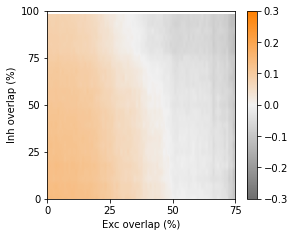

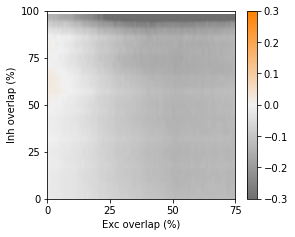

In [7]:
EPS = 1e-12

CSV_IALL = "data/fig6_7/iall_pattern_separation_stim_rates_summary_corrected.csv"
CSV_IE   = "data/fig6_7/ie_pattern_separation_stim_rates_summary_corrected.csv"

GREY_ORANGE = LinearSegmentedColormap.from_list(
    "grey_orange_dark",
    [
        (0.0, "#6e6e6e"), 
        (0.5, "#f1f1f1"),
        (1.0, "#ff8000"),
    ]
)

def compute_snr_df(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    needed = [
        "seed", "overlap_exc", "overlap_inh",
        "exc_rate_196_784", "exc_rate_784_1568_minus_7ov",
        "inh_rate_0_196", "inh_rate_196_392_minus_7ov",
    ]
    for c in needed:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["x"] = df["overlap_exc"] * 7.0 * 100.0 / 784.0      # 0–75 %
    df["y"] = df["overlap_inh"] * 7.0 * 100.0 / 196.0     # 0–100 %

    S_exc = df["exc_rate_196_784_minus_7ov"]
    N_exc = df["exc_rate_784_1568_minus_7ov"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    S_inh = df["inh_rate_0_196_minus_7ov"]
    N_inh = df["inh_rate_196_392_minus_7ov"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    df["case"] = label
    return df[["seed", "x", "y", "sn_exc", "sn_inh", "case"]].dropna()

def mean_over_seeds(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        df.groupby(["case", "x", "y"], as_index=False)[col]
          .mean()
          .rename(columns={col: "mean"})
    )

def make_diff_grid(df_iall: pd.DataFrame, df_ie: pd.DataFrame, col: str) -> pd.DataFrame:
    a = mean_over_seeds(df_iall, col)
    b = mean_over_seeds(df_ie, col)

    merged = a.merge(b, on=["x", "y"], how="outer", suffixes=("_iall", "_ie"))
    merged["diff"] = merged["mean_iall"] - merged["mean_ie"]

    return (
        merged.pivot(index="y", columns="x", values="diff")
              .sort_index()
              .sort_index(axis=1)
    )

def plot_heatmap(
    grid: pd.DataFrame,
    xlabel: str,
    ylabel: str
):
    Z = grid.values
    xvals = grid.columns.values
    yvals = grid.index.values

    dx = np.diff(xvals).mean() if len(xvals) > 1 else 1.0
    dy = np.diff(yvals).mean() if len(yvals) > 1 else 1.0

    extent = [
        xvals.min() - dx / 2,
        xvals.max() + dx / 2,
        yvals.min() - dy / 2,
        yvals.max() + dy / 2,
    ]

    norm = TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3)

    fig, ax = plt.subplots(figsize=(4.2, 3.4))
    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        cmap=GREY_ORANGE,
        norm=norm,
        extent=extent
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xlim(0, 75)
    ax.set_ylim(0, 100)

    ax.set_xticks([0, 25, 50, 75])
    ax.set_yticks([0, 25, 50, 75, 100])

    cbar = plt.colorbar(im, ax=ax)

    plt.tight_layout()

    return fig, ax

df_iall = compute_snr_df(CSV_IALL, "iall")
df_ie   = compute_snr_df(CSV_IE,   "ie")

grid_exc = make_diff_grid(df_iall, df_ie, "sn_exc")
grid_inh = make_diff_grid(df_iall, df_ie, "sn_inh")

plot_heatmap(
    grid_exc,
    "Exc overlap (%)",
    "Inh overlap (%)"
)

plot_heatmap(
    grid_inh,
    "Exc overlap (%)",
    "Inh overlap (%)"
)

plt.show()


## Fig 7: I-to-All plasticity enables disinhibitory recall of overlapping engrams.

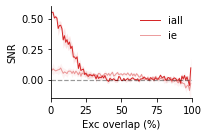

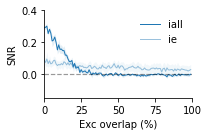

In [11]:
SHOW_SEM = True
EPS = 1e-12

CSV_IALL = "data/fig6_7/iall_pattern_separation_inhib_rates_summary_corrected.csv"
CSV_IE   = "data/fig6_7/ie_pattern_separation_inhib_rates_summary_corrected.csv"

BLUE = "#1f77b4"
RED  = "#d62728"

def load_and_compute(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    needed_cols = [
        "seed",
        "overlap_exc", "overlap_inh",
        "exc_rate_0_784_minus_7ov", "exc_rate_784_1568_minus_7ov",
        "inh_rate_98_196_minus_7ov", "inh_rate_196_392_minus_7ov",
    ]
    for c in needed_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df[df["overlap_inh"] == 0].copy()

    df["x"] = df["overlap_exc"] * 7.0 * 100.0 / 784.0

    S_exc = df["exc_rate_0_784_minus_7ov"]
    N_exc = df["exc_rate_784_1568_minus_7ov"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    S_inh = df["inh_rate_98_196_minus_7ov"]
    N_inh = df["inh_rate_196_392_minus_7ov"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    df["case"] = label
    return df[["x", "seed", "sn_exc", "sn_inh", "case"]].dropna(subset=["x", "sn_exc", "sn_inh"])

def aggregate_mean_sem(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    g = df.groupby("x")[ycol]
    out = g.mean().rename("mean").to_frame().reset_index()
    if SHOW_SEM:
        n = g.count().rename("n").reset_index()
        sd = g.std(ddof=1).rename("sd").reset_index()
        out = out.merge(n, on="x").merge(sd, on="x")
        out["sem"] = out["sd"] / np.sqrt(out["n"].replace(0, np.nan))
    else:
        out["sem"] = np.nan
    return out.sort_values("x")

df_iall = load_and_compute(CSV_IALL, "iall")
df_ie   = load_and_compute(CSV_IE,   "ie")

agg_iall_exc = aggregate_mean_sem(df_iall, "sn_exc")
agg_ie_exc   = aggregate_mean_sem(df_ie,   "sn_exc")

fig1, ax1 = plt.subplots(figsize=(3, 2))

ax1.plot(agg_iall_exc["x"], agg_iall_exc["mean"],
         color=RED, linewidth=1, label="iall")
ax1.plot(agg_ie_exc["x"], agg_ie_exc["mean"],
         color=RED, linewidth=1, alpha=0.45, label="ie")

if SHOW_SEM:
    ax1.fill_between(
        agg_iall_exc["x"],
        agg_iall_exc["mean"] - agg_iall_exc["sem"],
        agg_iall_exc["mean"] + agg_iall_exc["sem"],
        color=RED, alpha=0.12, linewidth=0
    )
    ax1.fill_between(
        agg_ie_exc["x"],
        agg_ie_exc["mean"] - agg_ie_exc["sem"],
        agg_ie_exc["mean"] + agg_ie_exc["sem"],
        color=RED, alpha=0.06, linewidth=0
    )

ax1.set_xlabel("Exc overlap (%)")
ax1.set_ylabel("SNR")

ax1.set_xlim(0, 100)
ax1.set_xticks([0, 25, 50, 75, 100])

ax1.set_ylim(-0.15, 0.6)
ax1.set_yticks([0, 0.25, 0.5])

ax1.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False)

plt.tight_layout()

agg_iall_inh = aggregate_mean_sem(df_iall, "sn_inh")
agg_ie_inh   = aggregate_mean_sem(df_ie,   "sn_inh")

fig2, ax2 = plt.subplots(figsize=(3, 2))

ax2.plot(agg_iall_inh["x"], agg_iall_inh["mean"],
         color=BLUE, linewidth=1, label="iall")
ax2.plot(agg_ie_inh["x"], agg_ie_inh["mean"],
         color=BLUE, linewidth=1, alpha=0.45, label="ie")

if SHOW_SEM:
    ax2.fill_between(
        agg_iall_inh["x"],
        agg_iall_inh["mean"] - agg_iall_inh["sem"],
        agg_iall_inh["mean"] + agg_iall_inh["sem"],
        color=BLUE, alpha=0.12, linewidth=0
    )
    ax2.fill_between(
        agg_ie_inh["x"],
        agg_ie_inh["mean"] - agg_ie_inh["sem"],
        agg_ie_inh["mean"] + agg_ie_inh["sem"],
        color=BLUE, alpha=0.06, linewidth=0
    )

ax2.set_xlabel("Exc overlap (%)")
ax2.set_ylabel("SNR")

ax2.set_xlim(0, 100)
ax2.set_xticks([0, 25, 50, 75, 100])

ax2.set_ylim(-0.15, 0.4)
ax2.set_yticks([0.0, 0.2, 0.4])

ax2.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()

plt.show()

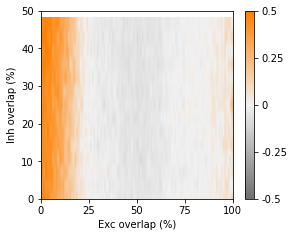

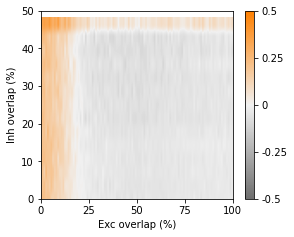

In [10]:
EPS = 1e-12

CSV_IALL = "data/fig6_7/iall_pattern_separation_inhib_rates_summary_corrected.csv"
CSV_IE   = "data/fig6_7/ie_pattern_separation_inhib_rates_summary_corrected.csv"

GREY_ORANGE = LinearSegmentedColormap.from_list(
    "grey_orange_dark",
    [
        (0.0, "#6e6e6e"),
        (0.5, "#f1f1f1"),
        (1.0, "#ff8000"),
    ]
)

def compute_snr_df(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    needed = [
        "seed", "overlap_exc", "overlap_inh",
        "exc_rate_0_784_minus_7ov", "exc_rate_784_1568_minus_7ov",
        "inh_rate_98_196_minus_7ov", "inh_rate_196_392_minus_7ov",
    ]
    for c in needed:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["x"] = df["overlap_exc"] * 7 * 100.0 / 784.0
    df["y"] = df["overlap_inh"] * 7 * 100.0 / 196.0

    S_exc = df["exc_rate_0_784_minus_7ov"]
    N_exc = df["exc_rate_784_1568_minus_7ov"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    S_inh = df["inh_rate_98_196_minus_7ov"]
    N_inh = df["inh_rate_196_392_minus_7ov"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    df["case"] = label
    return df[["seed", "x", "y", "sn_exc", "sn_inh", "case"]].dropna()

def mean_over_seeds(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        df.groupby(["case", "x", "y"], as_index=False)[col]
          .mean()
          .rename(columns={col: "mean"})
    )

def make_diff_grid(df_iall: pd.DataFrame, df_ie: pd.DataFrame, col: str) -> pd.DataFrame:
    a = mean_over_seeds(df_iall, col)
    b = mean_over_seeds(df_ie, col)

    merged = a.merge(b, on=["x", "y"], how="outer", suffixes=("_iall", "_ie"))
    merged["diff"] = merged["mean_iall"] - merged["mean_ie"]

    return (
        merged.pivot(index="y", columns="x", values="diff")
              .sort_index()
              .sort_index(axis=1)
    )

def plot_heatmap(
    grid: pd.DataFrame,
    xlabel: str,
    ylabel: str
):
    Z = grid.values
    xvals = grid.columns.values
    yvals = grid.index.values

    dx = np.diff(xvals).mean() if len(xvals) > 1 else 1.0
    dy = np.diff(yvals).mean() if len(yvals) > 1 else 1.0

    extent = [
        xvals.min() - dx / 2,
        xvals.max() + dx / 2,
        yvals.min() - dy / 2,
        yvals.max() + dy / 2,
    ]

    norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.0, vmax=0.5)

    fig, ax = plt.subplots(figsize=(4.2, 3.4))
    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        cmap=GREY_ORANGE,
        norm=norm,
        extent=extent
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)

    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_yticks([0, 10, 20, 30, 40, 50])

    cbar = plt.colorbar(im, ax=ax, ticks=[-0.5, -0.25, 0.0, 0.25, 0.5])
    cbar.ax.set_yticklabels(["-0.5", "-0.25", "0", "0.25", "0.5"])

    plt.tight_layout()

    return fig, ax

df_iall = compute_snr_df(CSV_IALL, "iall")
df_ie   = compute_snr_df(CSV_IE,   "ie")

grid_exc = make_diff_grid(df_iall, df_ie, "sn_exc")
grid_inh = make_diff_grid(df_iall, df_ie, "sn_inh")

plot_heatmap(grid_exc, "Exc overlap (%)", "Inh overlap (%)")
plot_heatmap(grid_inh, "Exc overlap (%)", "Inh overlap (%)")

plt.show()

